# TFM - SISTEMA DE ALERTA TEMPRANA CON REGRESIÓN LOGÍSTICA

Script lineal para ejecutar bloque por bloque en JupyterLab.

Archivo inicial esperado:
    mdl_integrado.csv

Cómo utilizarlo:
1. Coloque este script y mdl_integrado.csv en la misma carpeta.
2. Abra un notebook de JupyterLab en esa carpeta.
3. Copie y ejecute cada bloque en orden, o ejecute el archivo completo con:

       %run script_jupyter_modelo_alerta_bloques.py

Decisiones metodológicas:
- Se conservan únicamente cursos académicos cuyo nombre empieza con un número.
- Se excluyen los registros sin nota del primer parcial antes del entrenamiento.
- La nota del primer parcial se utiliza solo para construir ``riesgo_real``.
- La nota del primer parcial NO se utiliza como predictor.
- No se eliminan estudiantes por ausencia de cuestionarios o tareas.
- Los nulos de actividades se representan mediante ceros e indicadores
  semánticos que distinguen actividad no configurada de actividad no realizada.
- La muestra esperada con el archivo analizado es de 10.813 registros.

BLOQUE 1. Librerías y configuración general

Este bloque importa las librerías, fija la semilla de reproducibilidad y
define las rutas. Si el archivo tiene otro nombre, cambie únicamente
``RUTA_ENTRADA``.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import __version__ as VERSION_SKLEARN
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.calibration import (
    CalibratedClassifierCV,
    CalibrationDisplay,
)
from sklearn.metrics import brier_score_loss

try:
    from IPython.display import display
except ImportError:
    display = print


RUTA_ENTRADA = Path("mdl_integrado.csv")
CARPETA_SALIDA = Path("salidas_modelo_alerta")
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)

SEMILLA = 42
PROPORCION_PRUEBA = 0.30
NOTA_APROBACION = 7.0
UMBRAL_PREDICCION = 0.50
UMBRAL_NIVEL_BAJO = 0.35
UMBRAL_NIVEL_ALTO = 0.65
N_TRABAJOS = -1

np.random.seed(SEMILLA)
sns.set_theme(style="whitegrid")

print("Versión de scikit-learn:", VERSION_SKLEARN)
print("Archivo de entrada:", RUTA_ENTRADA.resolve())
print("Carpeta de salida:", CARPETA_SALIDA.resolve())

Versión de scikit-learn: 1.6.1
Archivo de entrada: C:\Users\ASUS\OneDrive\0.2 MAESTRIA EN BIG DATA\TFM\entrega_02\mdl_integrado.csv
Carpeta de salida: C:\Users\ASUS\OneDrive\0.2 MAESTRIA EN BIG DATA\TFM\entrega_02\salidas_modelo_alerta


BLOQUE 2. Carga del archivo original

El CSV está separado por punto y coma. También se admite un archivo Excel si
se cambia la extensión de ``RUTA_ENTRADA`` a .xlsx.

``df_original`` se conserva sin modificaciones para garantizar la
trazabilidad. Las transformaciones se realizan sobre copias.

In [2]:
if not RUTA_ENTRADA.exists():
    raise FileNotFoundError(
        f"No se encontró {RUTA_ENTRADA}. Coloque el archivo en la carpeta "
        "del notebook o cambie RUTA_ENTRADA en el bloque 1."
    )

if RUTA_ENTRADA.suffix.lower() == ".csv":
    df_original = pd.read_csv(
        RUTA_ENTRADA,
        sep=";",
        encoding="utf-8",
        low_memory=False,
    )
elif RUTA_ENTRADA.suffix.lower() in {".xlsx", ".xls"}:
    df_original = pd.read_excel(RUTA_ENTRADA, engine="openpyxl")
else:
    raise ValueError("El archivo debe tener extensión .csv, .xlsx o .xls.")

df_original.columns = df_original.columns.str.strip()

COLUMNAS_REQUERIDAS = [
    "curso_anonimo",
    "estudiante_anonimo",
    "total_sesiones_31d",
    "total_eventos_31d",
    "dias_activos_31d",
    "total_minutos_31d",
    "recursos_vistos_31d",
    "tareas_entregadas_31d",
    "cuestionarios_intentados_31d",
    "promedio_quizzes_31d",
    "numero_intentos_quiz_31d",
    "promedio_nota_tareas_31d",
    "Total_cuestionarios_curso",
    "Total_tareas_curso",
    "Total_Recursos_Curso",
    "curso",
    "nota_1_parcial",
]

columnas_faltantes = [
    columna
    for columna in COLUMNAS_REQUERIDAS
    if columna not in df_original.columns
]
if columnas_faltantes:
    raise ValueError(f"Faltan columnas requeridas: {columnas_faltantes}")

print(f"Dimensión inicial: {df_original.shape[0]:,} filas x "
      f"{df_original.shape[1]} columnas")
display(df_original.head())

Dimensión inicial: 43,634 filas x 17 columnas


,curso_anonimo,estudiante_anonimo,total_sesiones_31d,total_eventos_31d,dias_activos_31d,total_minutos_31d,recursos_vistos_31d,tareas_entregadas_31d,cuestionarios_intentados_31d,promedio_quizzes_31d,numero_intentos_quiz_31d,promedio_nota_tareas_31d,Total_cuestionarios_curso,Total_tareas_curso,Total_Recursos_Curso,curso,nota_1_parcial
0,008d738b2b95f97076b6c237de8ff6706fbcde63535a57...,0bb9f9f420a7781e1a5f9d62ff6b1846a35d161d470b1b...,29.0,150.0,4.0,39.40,4.0,4.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,1-A-MATEMATICA I,NaN
1,008d738b2b95f97076b6c237de8ff6706fbcde63535a57...,0f1275e48abd4af4ba25a4232d42e7c2dd2f1dccff3cf6...,46.0,143.0,7.0,62.00,4.0,4.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,1-A-MATEMATICA I,NaN
2,008d738b2b95f97076b6c237de8ff6706fbcde63535a57...,0f3a3f8a0d20097765edb32114bf16fe345d44af91e154...,1.0,6.0,1.0,0.68,1.0,1.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,1-A-MATEMATICA I,NaN
3,008d738b2b95f97076b6c237de8ff6706fbcde63535a57...,101288c058f03edd7590478ed291426c930a3bb103c9e8...,NaN,NaN,NaN,NaN,3.0,3.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,1-A-MATEMATICA I,NaN
4,008d738b2b95f97076b6c237de8ff6706fbcde63535a57...,210fcb6bb6f1d55d54d9ba8fc20053c3fc02ab8420a54d...,3.0,7.0,1.0,0.32,2.0,2.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,1-A-MATEMATICA I,NaN


BLOQUE 3. Auditoría inicial de calidad

Se revisan tipos, valores nulos y duplicados antes de modificar los datos.
Esta salida puede utilizarse como evidencia de la fase de comprensión y
calidad de datos del TFM.

In [3]:
auditoria_inicial = pd.DataFrame(
    {
        "tipo": df_original.dtypes.astype(str),
        "nulos": df_original.isna().sum(),
        "porcentaje_nulos": (
            df_original.isna().mean().mul(100).round(2)
        ),
        "valores_unicos": df_original.nunique(dropna=True),
    }
)

duplicados_exactos_iniciales = int(df_original.duplicated().sum())
duplicados_clave_iniciales = int(
    df_original.duplicated(
        subset=["curso_anonimo", "estudiante_anonimo"]
    ).sum()
)

print("Duplicados exactos:", duplicados_exactos_iniciales)
print(
    "Duplicados por curso-estudiante:",
    duplicados_clave_iniciales,
)
display(auditoria_inicial)

Duplicados exactos: 0
Duplicados por curso-estudiante: 0


,tipo,nulos,porcentaje_nulos,valores_unicos
curso_anonimo,object,0,0.00,1575
estudiante_anonimo,object,0,0.00,6872
total_sesiones_31d,float64,28318,64.90,517
total_eventos_31d,float64,28318,64.90,337
dias_activos_31d,float64,28318,64.90,20
total_minutos_31d,float64,28318,64.90,4264
recursos_vistos_31d,float64,26876,61.59,11
tareas_entregadas_31d,float64,27727,63.54,10
cuestionarios_intentados_31d,float64,42876,98.26,3
promedio_quizzes_31d,float64,42876,98.26,132


BLOQUE 4. Normalización técnica y selección de cursos académicos

Se eliminan espacios de campos de texto, se convierten las variables
numéricas y se conservan únicamente los cursos cuyo nombre comienza con un
número. Con el archivo analizado deben quedar 43.407 registros académicos.

In [4]:
df = df_original.copy()

COLUMNAS_TEXTO = [
    "curso_anonimo",
    "estudiante_anonimo",
    "curso",
]

COLUMNAS_NUMERICAS = [
    "total_sesiones_31d",
    "total_eventos_31d",
    "dias_activos_31d",
    "total_minutos_31d",
    "recursos_vistos_31d",
    "tareas_entregadas_31d",
    "cuestionarios_intentados_31d",
    "promedio_quizzes_31d",
    "numero_intentos_quiz_31d",
    "promedio_nota_tareas_31d",
    "Total_cuestionarios_curso",
    "Total_tareas_curso",
    "Total_Recursos_Curso",
    "nota_1_parcial",
]

for columna in COLUMNAS_TEXTO:
    df[columna] = df[columna].astype("string").str.strip()

for columna in COLUMNAS_NUMERICAS:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

mascara_identificadores = (
    df["curso_anonimo"].notna()
    & df["estudiante_anonimo"].notna()
    & df["curso_anonimo"].str.len().gt(0)
    & df["estudiante_anonimo"].str.len().gt(0)
)
df = df.loc[mascara_identificadores].copy()

mascara_curso_academico = df["curso"].str.match(r"^\d", na=False)
registros_no_academicos = int((~mascara_curso_academico).sum())
df_academico = df.loc[mascara_curso_academico].copy()

print("Registros administrativos eliminados:", registros_no_academicos)
print("Registros académicos:", f"{len(df_academico):,}")

Registros administrativos eliminados: 227
Registros académicos: 43,407


BLOQUE 5. Selección de resultados académicos conocidos

``nota_1_parcial`` es el resultado posterior que permite construir la
variable objetivo. Los registros sin esta nota se excluyen del entrenamiento,
pero la nota no se incluye entre los predictores.

Regla:
- riesgo_real = 1 cuando nota_1_parcial < 7.
- riesgo_real = 0 cuando nota_1_parcial >= 7.

Con el archivo analizado deben quedar exactamente 10.813 registros.

In [5]:
notas_nulas_excluidas = int(df_academico["nota_1_parcial"].isna().sum())
df_modelado = df_academico.loc[
    df_academico["nota_1_parcial"].notna()
].copy()

df_modelado["riesgo_real"] = (
    df_modelado["nota_1_parcial"].lt(NOTA_APROBACION).astype("int8")
)

distribucion_objetivo = (
    df_modelado["riesgo_real"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Sin riesgo (0)", 1: "En riesgo (1)"})
)

print("Notas parciales nulas excluidas:", f"{notas_nulas_excluidas:,}")
print("Registros disponibles para modelado:", f"{len(df_modelado):,}")
display(distribucion_objetivo.to_frame("registros"))

Notas parciales nulas excluidas: 32,594
Registros disponibles para modelado: 10,813


,registros
riesgo_real,
Sin riesgo (0),3052
En riesgo (1),7761


BLOQUE 6. Tratamiento semántico de valores nulos

No se eliminan estudiantes porque el curso no tenga cuestionarios, tareas o
recursos. La ausencia se representa con ceros e indicadores separados:

- ``curso_tiene_*``: indica si hay evidencia de configuración o utilización.
- ``tiene_nota_*``: indica si el estudiante posee una calificación.
- ``promedio_*_modelo``: usa cero únicamente como valor técnico, acompañado
  de los indicadores anteriores para evitar confundir "sin actividad" con
  una calificación real de cero.

In [6]:
COLUMNAS_ACTIVIDAD_CERO = [
    "total_sesiones_31d",
    "total_eventos_31d",
    "dias_activos_31d",
    "total_minutos_31d",
    "Total_Recursos_Curso",
    "recursos_vistos_31d",
    "Total_tareas_curso",
    "tareas_entregadas_31d",
    "cuestionarios_intentados_31d",
    "numero_intentos_quiz_31d",
]


df_modelado[COLUMNAS_ACTIVIDAD_CERO] = (
    df_modelado[COLUMNAS_ACTIVIDAD_CERO].fillna(0)
)

# ----------------------- Recursos del curso -------------------------------
df_modelado["curso_tiene_recursos_31d"] = (
    df_modelado["Total_Recursos_Curso"].gt(0).astype("int8")
)

df_modelado["tasa_recursos_vistos_31d"] = np.where(
    df_modelado["Total_Recursos_Curso"].gt(0),
    (
        df_modelado["recursos_vistos_31d"]
        / df_modelado["Total_Recursos_Curso"]
    ),
    0.0,
)
df_modelado["tasa_recursos_vistos_31d"] = (
    pd.Series(
        df_modelado["tasa_recursos_vistos_31d"],
        index=df_modelado.index,
    )
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
    .clip(lower=0.0, upper=1.0)
)

# ------------------------- Tareas del curso -------------------------------
df_modelado["curso_tiene_tareas_31d"] = (
    df_modelado["Total_tareas_curso"].gt(0).astype("int8")
)

df_modelado["ratio_cumplimiento_31d"] = np.where(
    df_modelado["Total_tareas_curso"].gt(0),
    (
        df_modelado["tareas_entregadas_31d"]
        / df_modelado["Total_tareas_curso"]
    ),
    0.0,
)
df_modelado["ratio_cumplimiento_31d"] = (
    pd.Series(
        df_modelado["ratio_cumplimiento_31d"],
        index=df_modelado.index,
    )
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
    .clip(lower=0.0, upper=1.0)
)

df_modelado["tiene_nota_tareas_31d"] = (
    df_modelado["promedio_nota_tareas_31d"].notna().astype("int8")
)
df_modelado["promedio_nota_tareas_modelo_31d"] = (
    df_modelado["promedio_nota_tareas_31d"].fillna(0.0)
)

# ---------------------- Cuestionarios del curso ---------------------------
# La evidencia se calcula con todos los registros académicos, no con la nota
# parcial ni con riesgo_real. Por ello no introduce fuga de información.
df_modelado["curso_tiene_quiz_31d"] = (
    df_modelado["Total_cuestionarios_curso"].gt(0).astype("int8")
)

df_modelado["tiene_nota_quiz_31d"] = (
    df_modelado["promedio_quizzes_31d"].notna().astype("int8")
)
df_modelado["promedio_quizzes_modelo_31d"] = (
    df_modelado["promedio_quizzes_31d"].fillna(0.0)
)


BLOQUE 7. Definición y validación de los predictores

Se utilizan únicamente indicadores disponibles durante las primeras cuatro
semanas. La lista no contiene ``nota_1_parcial`` ni ``riesgo_real``.

La validación final detiene la ejecución si algún predictor conserva nulos o
valores infinitos.

In [7]:
PREDICTORES = [
    # Acceso y actividad.
    "total_sesiones_31d",
    "total_eventos_31d",
    "dias_activos_31d",
    "total_minutos_31d",
    # Recursos.
    "curso_tiene_recursos_31d",
    "Total_Recursos_Curso",
    "recursos_vistos_31d",
    "tasa_recursos_vistos_31d",
    # Tareas.
    "curso_tiene_tareas_31d",
    "Total_tareas_curso",
    "tareas_entregadas_31d",
    "ratio_cumplimiento_31d",
    "tiene_nota_tareas_31d",
    "promedio_nota_tareas_modelo_31d",
    # Cuestionarios.
    "curso_tiene_quiz_31d",
    "cuestionarios_intentados_31d",
    "numero_intentos_quiz_31d",
    "tiene_nota_quiz_31d",
    "promedio_quizzes_modelo_31d",
]

X = df_modelado[PREDICTORES].copy()
y = df_modelado["riesgo_real"].copy()

conteo_nulos_predictores = X.isna().sum()
nulos_restantes = conteo_nulos_predictores[
    conteo_nulos_predictores.gt(0)
].to_dict()

if nulos_restantes:
    raise ValueError(
        f"Persisten nulos en los predictores: {nulos_restantes}"
    )
if not np.isfinite(X.to_numpy(dtype=float)).all():
    raise ValueError("Los predictores contienen valores infinitos.")
if y.isna().any():
    raise ValueError("La variable objetivo contiene valores nulos.")

print("Registros del modelo:", f"{len(X):,}")
print("Cantidad de predictores:", len(PREDICTORES))
print("Valores nulos en X:", int(X.isna().sum().sum()))
print("Valores nulos en y:", int(y.isna().sum()))

resumen_predictores = X.describe().T
display(resumen_predictores)

Registros del modelo: 10,813
Cantidad de predictores: 19
Valores nulos en X: 0
Valores nulos en y: 0


,count,mean,std,min,25%,50%,75%,max
total_sesiones_31d,10813.0,32.408490,88.830471,0.0,0.0,1.000000,24.0,1754.00
total_eventos_31d,10813.0,28.203551,56.036174,0.0,0.0,3.000000,35.0,1452.00
dias_activos_31d,10813.0,1.902895,2.791630,0.0,0.0,1.000000,3.0,20.00
total_minutos_31d,10813.0,18.276418,45.006215,0.0,0.0,0.150000,18.1,1954.45
curso_tiene_recursos_31d,10813.0,0.815777,0.387684,0.0,1.0,1.000000,1.0,1.00
Total_Recursos_Curso,10813.0,2.908629,2.851351,0.0,1.0,2.000000,4.0,19.00
recursos_vistos_31d,10813.0,2.021918,1.982484,0.0,0.0,2.000000,3.0,11.00
tasa_recursos_vistos_31d,10813.0,0.604683,0.428938,0.0,0.0,0.750000,1.0,1.00
curso_tiene_tareas_31d,10813.0,0.780449,0.413961,0.0,1.0,1.000000,1.0,1.00
Total_tareas_curso,10813.0,2.253306,2.154270,0.0,1.0,2.000000,3.0,12.00


BLOQUE 8. Partición estratificada de entrenamiento y prueba

La partición es 70/30, mantiene la distribución de riesgo y utiliza
``random_state=42``. Con 10.813 registros deben obtenerse:

- Entrenamiento: 7.569 registros.
- Prueba: 3.244 registros.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=PROPORCION_PRUEBA,
    random_state=SEMILLA,
    stratify=y,
)

print("Entrenamiento:", f"{len(X_train):,}")
print("Prueba:", f"{len(X_test):,}")

comparacion_clases = pd.DataFrame(
    {
        "Total": y.value_counts(normalize=True).sort_index(),
        "Entrenamiento": (
            y_train.value_counts(normalize=True).sort_index()
        ),
        "Prueba": y_test.value_counts(normalize=True).sort_index(),
    }
).rename(index={0: "Sin riesgo (0)", 1: "En riesgo (1)"})

comparacion_clases_porcentaje = (
    comparacion_clases.mul(100).round(2).astype(str) + "%"
)
display(comparacion_clases_porcentaje)

Entrenamiento: 7,569
Prueba: 3,244


,Total,Entrenamiento,Prueba
riesgo_real,,,
Sin riesgo (0),28.23%,28.22%,28.24%
En riesgo (1),71.77%,71.78%,71.76%


BLOQUE 9. Estandarización y búsqueda de hiperparámetros

``StandardScaler`` se ejecuta dentro del Pipeline y dentro de cada pliegue
de validación cruzada, evitando fuga de información.

Grid Search evalúa:
- C: 0,01; 0,1; 1 y 10.
- Regularización L1 y L2.
- Sin balanceo y con ``class_weight='balanced'``.

El criterio de selección es F1 macro para considerar ambas clases.

In [9]:
def version_sklearn_mayor_igual(major: int, minor: int) -> bool:
    partes = []
    for fragmento in VERSION_SKLEARN.split(".")[:2]:
        digitos = "".join(c for c in fragmento if c.isdigit())
        partes.append(int(digitos or 0))
    return tuple(partes) >= (major, minor)


pipeline_logistica = Pipeline(
    steps=[
        ("escalador", StandardScaler()),
        (
            "clasificador",
            LogisticRegression(
                solver="liblinear",
                max_iter=2_000,
                random_state=SEMILLA,
            ),
        ),
    ]
)

if version_sklearn_mayor_igual(1, 8):
    # En versiones nuevas, l1_ratio=0 equivale a L2 y l1_ratio=1 a L1.
    rejilla_parametros = {
        "clasificador__C": [0.01, 0.1, 1.0, 10.0],
        "clasificador__l1_ratio": [0.0, 1.0],
        "clasificador__class_weight": [None, "balanced"],
    }
else:
    # Compatible con scikit-learn 1.1.3.
    rejilla_parametros = {
        "clasificador__C": [0.01, 0.1, 1.0, 10.0],
        "clasificador__penalty": ["l1", "l2"],
        "clasificador__class_weight": [None, "balanced"],
    }

validacion_cruzada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEMILLA,
)

metricas_grid = {
    "f1_riesgo": "f1",
    "f1_macro": "f1_macro",
    "exactitud_balanceada": "balanced_accuracy",
    "roc_auc": "roc_auc",
}

busqueda_modelo = GridSearchCV(
    estimator=pipeline_logistica,
    param_grid=rejilla_parametros,
    scoring=metricas_grid,
    refit="f1_macro",
    cv=validacion_cruzada,
    n_jobs=N_TRABAJOS,
    return_train_score=True,
    error_score="raise",
)

busqueda_modelo.fit(X_train, y_train)
modelo_final = busqueda_modelo.best_estimator_

# Calibración compatible con diferentes versiones de scikit-learn
try:
    # Versiones nuevas de scikit-learn
    modelo_calibrado = CalibratedClassifierCV(
        estimator=modelo_final,
        method="sigmoid",
        cv=5,
        n_jobs=N_TRABAJOS
    )
except TypeError:
    # Versiones anteriores de scikit-learn
    modelo_calibrado = CalibratedClassifierCV(
        base_estimator=modelo_final,
        method="sigmoid",
        cv=5,
        n_jobs=N_TRABAJOS
    )

modelo_calibrado.fit(X_train, y_train)

print("Modelo calibrado correctamente.")
print("Mejores hiperparámetros:")
print(busqueda_modelo.best_params_)
print(
    "Mejor F1 macro en validación cruzada:",
    round(float(busqueda_modelo.best_score_), 4),
)

Modelo calibrado correctamente.
Mejores hiperparámetros:
{'clasificador__C': 10.0, 'clasificador__class_weight': 'balanced', 'clasificador__penalty': 'l1'}
Mejor F1 macro en validación cruzada: 0.6298


Mejores hiperparámetros:
{'clasificador__C': 10.0, 'clasificador__class_weight': 'balanced', 'clasificador__penalty': 'l1'}
Mejor F1 macro en validación cruzada: 0.6298
Configuraciones evaluadas: 16
Entrenamientos realizados: 80


,Posición,C,Penalización,Balanceo,F1 macro validación,Desviación,F1 macro entrenamiento,Brecha
0,1,10.00,L1,Balanceado,0.6298,0.0184,0.6300,0.0003
1,2,10.00,L2,Balanceado,0.6294,0.0182,0.6300,0.0006
2,3,1.00,L1,Balanceado,0.6290,0.0181,0.6293,0.0004
3,4,1.00,L2,Balanceado,0.6289,0.0180,0.6295,0.0006
4,5,0.10,L2,Balanceado,0.6269,0.0194,0.6281,0.0013
5,6,0.10,L1,Balanceado,0.6245,0.0194,0.6265,0.0019
6,7,0.01,L2,Balanceado,0.6176,0.0196,0.6205,0.0029
7,8,0.01,L1,Balanceado,0.5771,0.0155,0.5778,0.0007
8,9,10.00,L2,Sin balanceo,0.5689,0.0091,0.5760,0.0072
9,9,10.00,L1,Sin balanceo,0.5689,0.0091,0.5760,0.0072


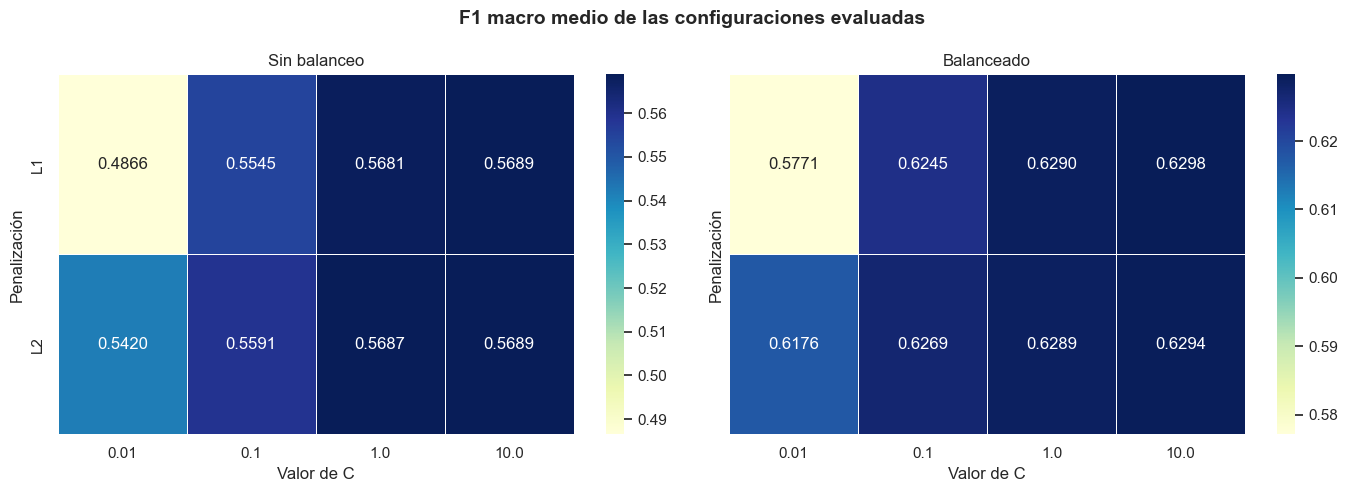

Modelo calibrado correctamente.


In [11]:
# ============================================================
# BLOQUE 9. ENTRENAMIENTO Y OPTIMIZACIÓN
# Compatible con scikit-learn 1.1.3
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV


# ------------------------------------------------------------
# 1. Pipeline: estandarización + regresión logística
# ------------------------------------------------------------

pipeline_logistica = Pipeline(
    steps=[
        ("escalador", StandardScaler()),
        (
            "clasificador",
            LogisticRegression(
                solver="liblinear",
                max_iter=2000,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# 2. Configuraciones que serán evaluadas
# ------------------------------------------------------------

rejilla_parametros = {
    "clasificador__C": [0.01, 0.1, 1.0, 10.0],
    "clasificador__penalty": ["l1", "l2"],
    "clasificador__class_weight": [None, "balanced"]
}

# Se evaluarán:
# 4 valores de C × 2 penalizaciones × 2 pesos = 16 configuraciones


# ------------------------------------------------------------
# 3. Validación cruzada estratificada
# ------------------------------------------------------------

validacion_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42 )


# ------------------------------------------------------------
# 4. Métricas calculadas
# ------------------------------------------------------------

metricas = {
    "f1_riesgo": "f1",
    "f1_macro": "f1_macro",
    "exactitud_balanceada": "balanced_accuracy",
    "roc_auc": "roc_auc"
}


# ------------------------------------------------------------
# 5. Búsqueda de la mejor configuración
# ------------------------------------------------------------

busqueda_modelo = GridSearchCV(
    estimator=pipeline_logistica,
    param_grid=rejilla_parametros,
    scoring=metricas,

    # El mejor modelo se elige por el mayor F1 macro
    refit="f1_macro",

    cv=validacion_cruzada,
    n_jobs=-1,
    return_train_score=True,
    error_score="raise"
)

busqueda_modelo.fit(X_train, y_train)

modelo_final = busqueda_modelo.best_estimator_


# ------------------------------------------------------------
# 6. Mostrar el resultado seleccionado
# ------------------------------------------------------------

print("Mejores hiperparámetros:")
print(busqueda_modelo.best_params_)

print(
    "Mejor F1 macro en validación cruzada:",
    round(busqueda_modelo.best_score_, 4)
)

print("Configuraciones evaluadas:", 16)
print("Entrenamientos realizados:", 16 * 5)


# ------------------------------------------------------------
# 7. Tabla comparativa de las configuraciones
# ------------------------------------------------------------

resultados = pd.DataFrame(
    busqueda_modelo.cv_results_
)

resultados["C"] = pd.to_numeric(
    resultados["param_clasificador__C"]
)

resultados["Penalización"] = (
    resultados["param_clasificador__penalty"]
    .astype(str)
    .str.upper()
)

resultados["Balanceo"] = resultados[
    "param_clasificador__class_weight"
].apply(
    lambda valor:
    "Sin balanceo" if valor is None else "Balanceado"
)

# Diferencia entre entrenamiento y validación
resultados["Brecha"] = (
    resultados["mean_train_f1_macro"]
    - resultados["mean_test_f1_macro"]
)

tabla_resultados = resultados[
    [
        "rank_test_f1_macro",
        "C",
        "Penalización",
        "Balanceo",
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "mean_train_f1_macro",
        "Brecha"
    ]
].copy()

tabla_resultados.columns = [
    "Posición",
    "C",
    "Penalización",
    "Balanceo",
    "F1 macro validación",
    "Desviación",
    "F1 macro entrenamiento",
    "Brecha"
]

tabla_resultados = (
    tabla_resultados
    .sort_values("Posición")
    .round(4)
    .reset_index(drop=True)
)

display(tabla_resultados)


# ------------------------------------------------------------
# 8. Mapa de calor para el TFM
# ------------------------------------------------------------

fig, ejes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharey=True
)

opciones_balanceo = [
    "Sin balanceo",
    "Balanceado"
]

for eje, opcion in zip(ejes, opciones_balanceo):

    datos = resultados[
        resultados["Balanceo"] == opcion
    ]

    matriz = datos.pivot(
        index="Penalización",
        columns="C",
        values="mean_test_f1_macro"
    )

    sns.heatmap(
        matriz,
        annot=True,
        fmt=".4f",
        cmap="YlGnBu",
        linewidths=0.5,
        ax=eje
    )

    eje.set_title(opcion)
    eje.set_xlabel("Valor de C")
    eje.set_ylabel("Penalización")

plt.suptitle(
    "F1 macro medio de las configuraciones evaluadas",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "figura_gridsearch_f1_macro.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 9. Calibración del modelo seleccionado
# ------------------------------------------------------------
modelo_calibrado = CalibratedClassifierCV(
    estimator=modelo_final,
    method="sigmoid",
    cv=validacion_cruzada,
    n_jobs=-1
)

modelo_calibrado.fit(X_train, y_train)

print("Modelo calibrado correctamente.")

BLOQUE 10. Evaluación sobre el conjunto de prueba

``probabilidad_riesgo`` se obtiene con ``predict_proba``.
``prediccion_riesgo`` utiliza un umbral de 0,50.

Se reportan métricas adecuadas para clases desbalanceadas y se compara el
modelo con una línea base que siempre predice la clase mayoritaria.

In [12]:
# Probabilidades del modelo antes de la calibración
probabilidad_sin_calibrar = modelo_final.predict_proba(X_test)[:, 1]

# Probabilidades después de la calibración sigmoide
probabilidad_riesgo = modelo_calibrado.predict_proba(X_test)[:, 1]

# Predicción binaria utilizando el modelo calibrado
prediccion_riesgo = (
    probabilidad_riesgo >= UMBRAL_PREDICCION
).astype("int8")

# Evaluación de la calidad de las probabilidades
brier_sin_calibrar = brier_score_loss(
    y_test,
    probabilidad_sin_calibrar,
)

brier_calibrado = brier_score_loss(
    y_test,
    probabilidad_riesgo,
)

print("EVALUACIÓN DE LA CALIBRACIÓN")
print(f"Brier score sin calibrar: {brier_sin_calibrar:.4f}")
print(f"Brier score calibrado: {brier_calibrado:.4f}")



linea_base = DummyClassifier(strategy="most_frequent")
linea_base.fit(X_train, y_train)
prediccion_base = linea_base.predict(X_test)

matriz_confusion = confusion_matrix(
    y_test,
    prediccion_riesgo,
    labels=[0, 1],
)
tn, fp, fn, tp = matriz_confusion.ravel()

metricas_modelo = {
    "accuracy": accuracy_score(y_test, prediccion_riesgo),
    "balanced_accuracy": balanced_accuracy_score(
        y_test, prediccion_riesgo
    ),
    "precision_riesgo": precision_score(
        y_test, prediccion_riesgo, zero_division=0
    ),
    "recall_riesgo": recall_score(
        y_test, prediccion_riesgo, zero_division=0
    ),
    "f1_riesgo": f1_score(
        y_test, prediccion_riesgo, zero_division=0
    ),
    "f1_macro": f1_score(
        y_test,
        prediccion_riesgo,
        average="macro",
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(y_test, probabilidad_riesgo),
    "average_precision": average_precision_score(
        y_test, probabilidad_riesgo
    ),      # Métricas de calibración
    "brier_sin_calibrar": brier_sin_calibrar,
    "brier_calibrado": brier_calibrado,
    "verdaderos_negativos": int(tn),
    "falsos_positivos": int(fp),
    "falsos_negativos": int(fn),
    "verdaderos_positivos": int(tp),
}

metricas_linea_base = {
    "accuracy": accuracy_score(y_test, prediccion_base),
    "balanced_accuracy": balanced_accuracy_score(
        y_test, prediccion_base
    ),
    "f1_macro": f1_score(
        y_test,
        prediccion_base,
        average="macro",
        zero_division=0,
    ),
}

print("REPORTE DE CLASIFICACIÓN")
print(
    classification_report(
        y_test,
        prediccion_riesgo,
        target_names=["Sin riesgo (0)", "En riesgo (1)"],
        digits=4,
        zero_division=0,
    )
)

tabla_metricas = pd.DataFrame(
    {
        "Regresión logística": {
            "Accuracy": metricas_modelo["accuracy"],
            "Balanced accuracy": metricas_modelo["balanced_accuracy"],
            "F1 macro": metricas_modelo["f1_macro"],
            "F1 riesgo": metricas_modelo["f1_riesgo"],
            "ROC-AUC": metricas_modelo["roc_auc"],
        },
        "Línea base": {
            "Accuracy": metricas_linea_base["accuracy"],
            "Balanced accuracy": metricas_linea_base[
                "balanced_accuracy"
            ],
            "F1 macro": metricas_linea_base["f1_macro"],
            "F1 riesgo": f1_score(
                y_test,
                prediccion_base,
                zero_division=0,
            ),
            "ROC-AUC": 0.5,
        },
    }
)
display(tabla_metricas.round(4))

EVALUACIÓN DE LA CALIBRACIÓN
Brier score sin calibrar: 0.2134
Brier score calibrado: 0.1747
REPORTE DE CLASIFICACIÓN
                precision    recall  f1-score   support

Sin riesgo (0)     0.6385    0.1812    0.2823       916
 En riesgo (1)     0.7487    0.9596    0.8411      2328

      accuracy                         0.7398      3244
     macro avg     0.6936    0.5704    0.5617      3244
  weighted avg     0.7175    0.7398    0.6833      3244



,Regresión logística,Línea base
Accuracy,0.7398,0.7176
Balanced accuracy,0.5704,0.5000
F1 macro,0.5617,0.4178
F1 riesgo,0.8411,0.8356
ROC-AUC,0.7229,0.5000


BLOQUE 11. Visualizaciones de evaluación

Se generan la matriz de confusión, curva ROC y curva precisión-recall.
Cada figura se muestra en JupyterLab y se guarda en la carpeta de salida.

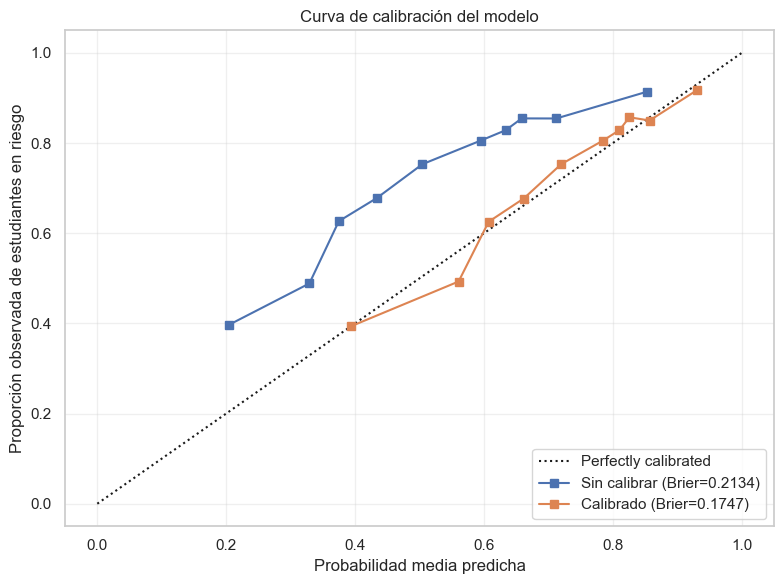

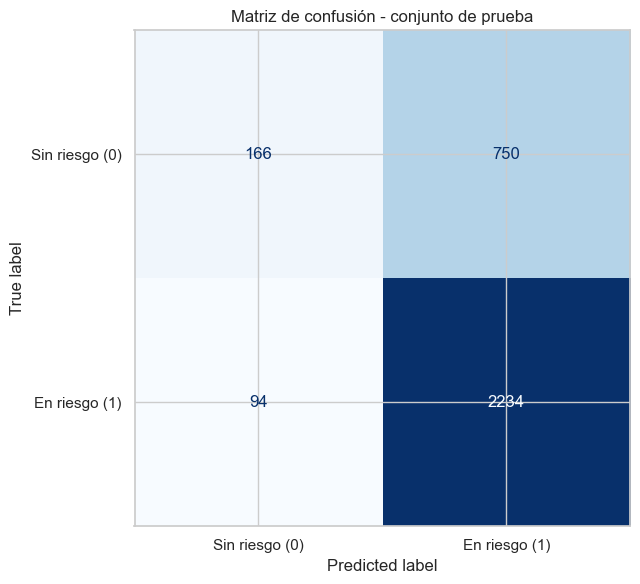

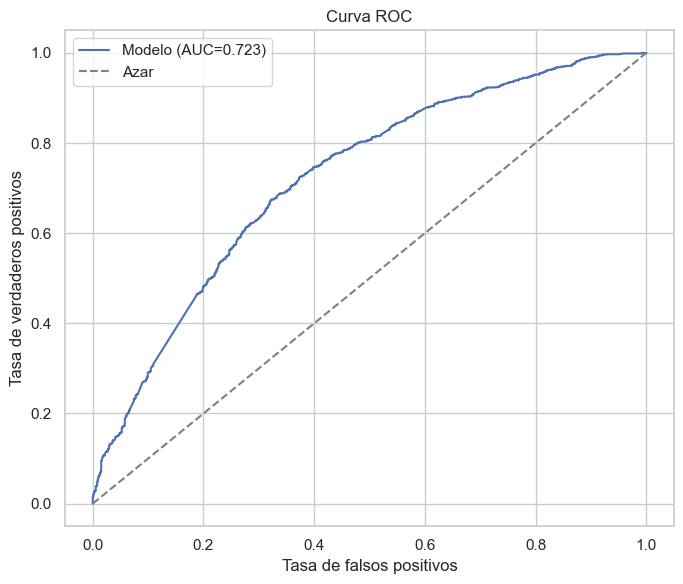

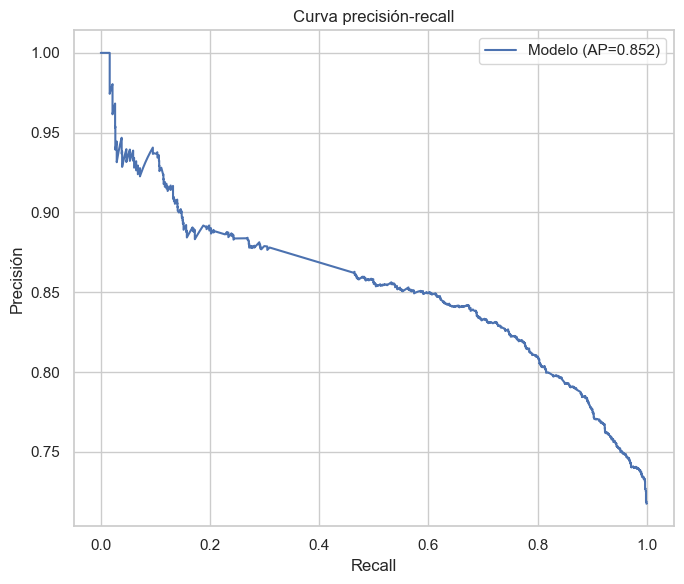

In [13]:
# ============================================================
# CURVA DE CALIBRACIÓN
# ============================================================

figura, eje = plt.subplots(figsize=(8, 6))

CalibrationDisplay.from_predictions(
    y_test,
    probabilidad_sin_calibrar,
    n_bins=10,
    strategy="quantile",
    name=(
        "Sin calibrar "
        f"(Brier={brier_sin_calibrar:.4f})"
    ),
    ax=eje,
)

CalibrationDisplay.from_predictions(
    y_test,
    probabilidad_riesgo,
    n_bins=10,
    strategy="quantile",
    name=(
        "Calibrado "
        f"(Brier={brier_calibrado:.4f})"
    ),
    ax=eje,
)

eje.set_title("Curva de calibración del modelo")
eje.set_xlabel("Probabilidad media predicha")
eje.set_ylabel("Proporción observada de estudiantes en riesgo")
eje.grid(alpha=0.3)

figura.tight_layout()
figura.savefig(
    CARPETA_SALIDA / "curva_calibracion.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


figura, eje = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=["Sin riesgo (0)", "En riesgo (1)"],
).plot(
    ax=eje,
    cmap="Blues",
    values_format="d",
    colorbar=False,
)
eje.set_title("Matriz de confusión - conjunto de prueba")
figura.tight_layout()
figura.savefig(
    CARPETA_SALIDA / "matriz_confusion.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

fpr, tpr, _ = roc_curve(y_test, probabilidad_riesgo)
figura, eje = plt.subplots(figsize=(7, 6))
eje.plot(
    fpr,
    tpr,
    label=f"Modelo (AUC={metricas_modelo['roc_auc']:.3f})",
)
eje.plot([0, 1], [0, 1], "--", color="gray", label="Azar")
eje.set_xlabel("Tasa de falsos positivos")
eje.set_ylabel("Tasa de verdaderos positivos")
eje.set_title("Curva ROC")
eje.legend()
figura.tight_layout()
figura.savefig(
    CARPETA_SALIDA / "curva_roc.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

precision_curva, recall_curva, _ = precision_recall_curve(
    y_test,
    probabilidad_riesgo,
)
figura, eje = plt.subplots(figsize=(7, 6))
eje.plot(
    recall_curva,
    precision_curva,
    label=(
        "Modelo "
        f"(AP={metricas_modelo['average_precision']:.3f})"
    ),
)
eje.set_xlabel("Recall")
eje.set_ylabel("Precisión")
eje.set_title("Curva precisión-recall")
eje.legend()
figura.tight_layout()
figura.savefig(
    CARPETA_SALIDA / "curva_precision_recall.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

BLOQUE 12. Interpretación de los coeficientes

Como los predictores fueron estandarizados dentro del Pipeline, las
magnitudes de los coeficientes son comparables. Un signo positivo aumenta la
probabilidad estimada de riesgo; un signo negativo la reduce.

,predictor,coeficiente_estandarizado,magnitud_absoluta,direccion
13,promedio_nota_tareas_modelo_31d,-1.334920,1.334920,Reduce el riesgo
17,tiene_nota_quiz_31d,0.900471,0.900471,Aumenta el riesgo
18,promedio_quizzes_modelo_31d,-0.730325,0.730325,Reduce el riesgo
6,recursos_vistos_31d,0.676576,0.676576,Aumenta el riesgo
12,tiene_nota_tareas_31d,0.614044,0.614044,Aumenta el riesgo
10,tareas_entregadas_31d,-0.545831,0.545831,Reduce el riesgo
8,curso_tiene_tareas_31d,0.533404,0.533404,Aumenta el riesgo
15,cuestionarios_intentados_31d,-0.417312,0.417312,Reduce el riesgo
9,Total_tareas_curso,-0.406882,0.406882,Reduce el riesgo
4,curso_tiene_recursos_31d,-0.384048,0.384048,Reduce el riesgo


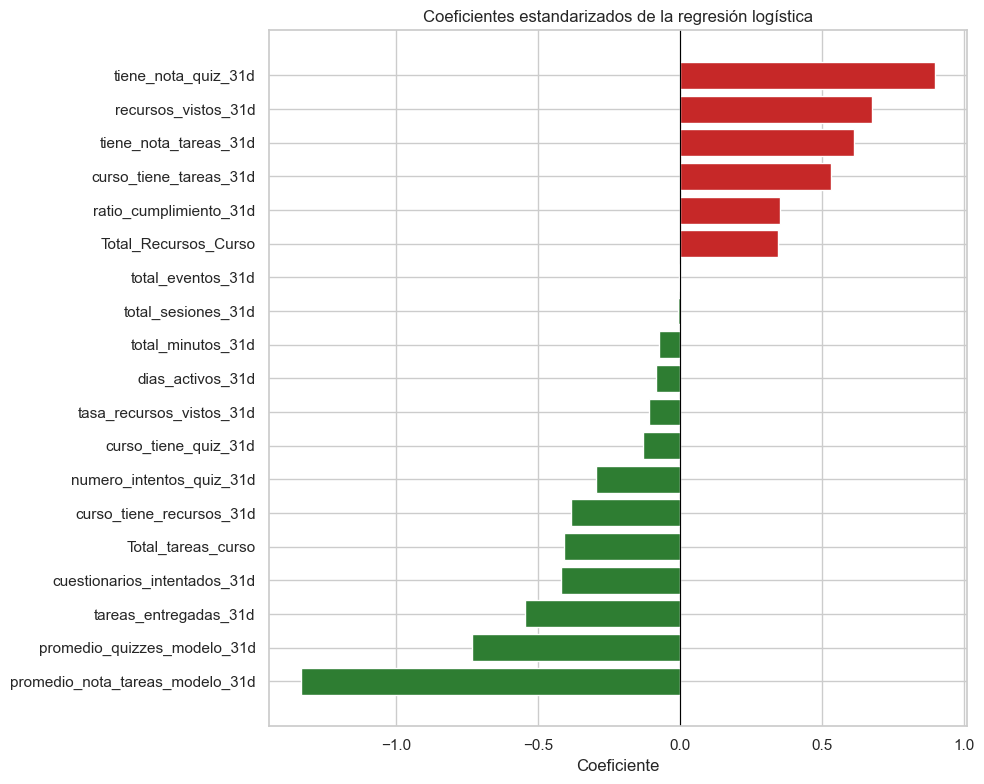

In [14]:
clasificador_final = modelo_final.named_steps["clasificador"]
coeficientes = clasificador_final.coef_.ravel()

tabla_coeficientes = pd.DataFrame(
    {
        "predictor": PREDICTORES,
        "coeficiente_estandarizado": coeficientes,
        "magnitud_absoluta": np.abs(coeficientes),
        "direccion": np.where(
            coeficientes > 0,
            "Aumenta el riesgo",
            "Reduce el riesgo",
        ),
    }
).sort_values("magnitud_absoluta", ascending=False)

display(tabla_coeficientes)

figura, eje = plt.subplots(figsize=(10, 8))
tabla_grafico = tabla_coeficientes.sort_values(
    "coeficiente_estandarizado"
)
colores = np.where(
    tabla_grafico["coeficiente_estandarizado"].gt(0),
    "#C62828",
    "#2E7D32",
)
eje.barh(
    tabla_grafico["predictor"],
    tabla_grafico["coeficiente_estandarizado"],
    color=colores,
)
eje.axvline(0, color="black", linewidth=0.8)
eje.set_title("Coeficientes estandarizados de la regresión logística")
eje.set_xlabel("Coeficiente")
figura.tight_layout()
figura.savefig(
    CARPETA_SALIDA / "coeficientes_modelo.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

BLOQUE 13. Preparación del archivo para Power BI

Se recuperan los identificadores correspondientes exactamente a las filas de
prueba y se añaden los resultados reales del modelo:

- riesgo_real: resultado observado.
- probabilidad_riesgo: probabilidad calculada por el modelo.
- prediccion_riesgo: 0 o 1 según el umbral de 0,50.
- nivel_riesgo: segmentación para los visuales.

In [15]:
columnas_contexto = [
    "curso_anonimo",
    "estudiante_anonimo",
    "curso",
    *PREDICTORES,
    "nota_1_parcial",
    "riesgo_real",
]

resultado_power_bi = df_modelado.loc[
    X_test.index,
    columnas_contexto,
].copy()

resultado_power_bi["probabilidad_riesgo"] = np.round(
    probabilidad_riesgo,
    6,
)
resultado_power_bi["prediccion_riesgo"] = prediccion_riesgo
resultado_power_bi["clasificacion_riesgo"] = np.where(
    resultado_power_bi["prediccion_riesgo"].eq(1),
    "En riesgo",
    "Sin riesgo",
)
resultado_power_bi["nivel_riesgo"] = np.select(
    [
        resultado_power_bi["probabilidad_riesgo"].lt(
            UMBRAL_NIVEL_BAJO
        ),
        resultado_power_bi["probabilidad_riesgo"].lt(
            UMBRAL_NIVEL_ALTO
        ),
    ],
    ["Bajo", "Medio"],
    default="Alto",
)
resultado_power_bi["origen_prediccion"] = (
    "MODELO REAL - CONJUNTO DE PRUEBA"
)

if resultado_power_bi.isna().any().any():
    nulos_salida = resultado_power_bi.isna().sum()
    raise ValueError(
        "El archivo de Power BI contiene nulos: "
        f"{nulos_salida[nulos_salida.gt(0)].to_dict()}"
    )

print("Registros preparados para Power BI:", len(resultado_power_bi))
display(resultado_power_bi.head())

Registros preparados para Power BI: 3244


,curso_anonimo,estudiante_anonimo,curso,total_sesiones_31d,total_eventos_31d,dias_activos_31d,total_minutos_31d,curso_tiene_recursos_31d,Total_Recursos_Curso,recursos_vistos_31d,...,numero_intentos_quiz_31d,tiene_nota_quiz_31d,promedio_quizzes_modelo_31d,nota_1_parcial,riesgo_real,probabilidad_riesgo,prediccion_riesgo,clasificacion_riesgo,nivel_riesgo,origen_prediccion
20367,7330f04735a7dc05d2685d64adfb0238cc22ecfd6b9cf0...,446fc22eca5780ec004467c31afff60254bc9bc10348b9...,1-A-EPISTEMOLOGIA Y METODOLOGIA DE LA INVESTIG...,72.0,25.0,4.0,3.92,1,1.0,1.0,...,0.0,0,0.00,5.85,1,0.860368,1,En riesgo,Alto,MODELO REAL - CONJUNTO DE PRUEBA
31564,b949ee785addc8114628ed3ab396dc277ca927c9720b94...,4fb615e6e5c3c629542a3576bc1cad7b56ccd499c9cc28...,4-B-ENSENANZA APRENDIZAJE DEL MEDIO ...,0.0,0.0,0.0,0.00,1,14.0,6.0,...,3.0,1,9.58,3.71,1,0.840155,1,En riesgo,Alto,MODELO REAL - CONJUNTO DE PRUEBA
30528,b19aee70113a34bda01a5812d43b0181d38a14c4bdbccc...,a0bc8ebf366e7dcab6ca6994549feaffb02685a431bcea...,6-B-GENERO Y TRABAJO SOCIAL,0.0,0.0,0.0,0.00,1,8.0,8.0,...,0.0,0,0.00,0.15,1,0.949393,1,En riesgo,Alto,MODELO REAL - CONJUNTO DE PRUEBA
35324,d0df676efeed6e779cc11cc8e12310e62fee902374cad4...,530fd215cc36cfe3aa152092814e71dd639104eb145115...,6-A-ENSENANZA APRENDIZAJE MATEMATICA II. DISE...,0.0,0.0,0.0,0.00,0,0.0,0.0,...,0.0,0,0.00,7.25,0,0.810384,1,En riesgo,Alto,MODELO REAL - CONJUNTO DE PRUEBA
34488,cb62c10a56507e3b97c04a19a58a346cb68917ebc21307...,ca9ef03c8c2bd6a6b621be3f5296535e422d5f094ee768...,1-A-TECNOLOGIA DE LA INFORMACION APLICADA A LA...,0.0,0.0,0.0,0.00,0,0.0,0.0,...,0.0,0,0.00,9.66,0,0.810384,1,En riesgo,Alto,MODELO REAL - CONJUNTO DE PRUEBA


BLOQUE 14. Exportación de resultados y modelo entrenado

Las salidas quedan disponibles en ``salidas_modelo_alerta``. El archivo
principal para Power BI es ``predicciones_prueba_3244.xlsx``.

In [16]:
def convertir_json(valor: Any) -> Any:
    if isinstance(valor, dict):
        return {str(k): convertir_json(v) for k, v in valor.items()}
    if isinstance(valor, (list, tuple)):
        return [convertir_json(v) for v in valor]
    if isinstance(valor, np.ndarray):
        return valor.tolist()
    if isinstance(valor, (np.integer,)):
        return int(valor)
    if isinstance(valor, (np.floating,)):
        return float(valor)
    if isinstance(valor, Path):
        return str(valor)
    return valor


dataset_modelo_sin_nulos = df_modelado.loc[
    :,
    columnas_contexto,
].copy()

if dataset_modelo_sin_nulos.isna().any().any():
    raise ValueError(
        "El dataset final del modelo todavía contiene valores nulos."
    )

ruta_dataset_modelo = (
    CARPETA_SALIDA / "dataset_modelo_10813_sin_nulos.xlsx"
)
ruta_predicciones = (
    CARPETA_SALIDA
    / f"predicciones_prueba_{len(resultado_power_bi)}.xlsx"
)
ruta_coeficientes = (
    CARPETA_SALIDA / "coeficientes_regresion_logistica.xlsx"
)
ruta_metricas = CARPETA_SALIDA / "metricas_modelo.json"
ruta_reporte = CARPETA_SALIDA / "reporte_clasificacion.txt"
ruta_modelo = CARPETA_SALIDA / "modelo_alerta_temprana.joblib"
ruta_grid = CARPETA_SALIDA / "resultados_grid_logistica.csv"

dataset_modelo_sin_nulos.to_excel(
    ruta_dataset_modelo,
    index=False,
    engine="openpyxl",
)
resultado_power_bi.to_excel(
    ruta_predicciones,
    index=False,
    engine="openpyxl",
)
tabla_coeficientes.to_excel(
    ruta_coeficientes,
    index=False,
    engine="openpyxl",
)

resultados_grid = pd.DataFrame(busqueda_modelo.cv_results_)
columnas_grid = [
    columna
    for columna in resultados_grid.columns
    if (
        columna.startswith("param_")
        or columna.startswith("mean_test_")
        or columna.startswith("std_test_")
        or columna.startswith("rank_test_")
    )
]
resultados_grid[columnas_grid].sort_values(
    "rank_test_f1_macro"
).to_csv(
    ruta_grid,
    index=False,
    encoding="utf-8-sig",
)

reporte_texto = classification_report(
    y_test,
    prediccion_riesgo,
    target_names=["Sin riesgo (0)", "En riesgo (1)"],
    digits=4,
    zero_division=0,
)
ruta_reporte.write_text(reporte_texto, encoding="utf-8")

paquete_modelo = {
    "modelo": modelo_calibrado,
    "modelo_logistico_base": modelo_final,
    "probabilidad_calibrada": True,
    "metodo_calibracion": "sigmoid",
    "predictores": PREDICTORES,
    "umbral_prediccion": UMBRAL_PREDICCION,
    "umbrales_nivel": {
        "bajo_hasta": UMBRAL_NIVEL_BAJO,
        "alto_desde": UMBRAL_NIVEL_ALTO,
    },
    "nota_aprobacion": NOTA_APROBACION,
    "semilla": SEMILLA,
    "regla_objetivo": (
        "Excluir nota_1_parcial nula; riesgo_real=1 si nota<7, "
        "riesgo_real=0 si nota>=7."
    ),
}
joblib.dump(paquete_modelo, ruta_modelo)

resumen_ejecucion = {
    "fuente": str(RUTA_ENTRADA),
    "registros_originales": len(df_original),
    "registros_academicos": len(df_academico),
    "notas_nulas_excluidas": notas_nulas_excluidas,
    "registros_modelado": len(df_modelado),
    "registros_entrenamiento": len(X_train),
    "registros_prueba": len(X_test),
    "cantidad_predictores": len(PREDICTORES),
    "mejores_hiperparametros": busqueda_modelo.best_params_,
    "metricas_modelo": metricas_modelo,
    "metricas_linea_base": metricas_linea_base,
    "salidas": {
        "dataset_modelo": ruta_dataset_modelo,
        "predicciones_power_bi": ruta_predicciones,
        "coeficientes": ruta_coeficientes,
        "metricas": ruta_metricas,
        "reporte": ruta_reporte,
        "modelo": ruta_modelo,
        "grid_search": ruta_grid,
    },
}

ruta_metricas.write_text(
    json.dumps(
        convertir_json(resumen_ejecucion),
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print("\nPROCESO FINALIZADO")
print("Dataset del modelo:", ruta_dataset_modelo)
print("Predicciones para Power BI:", ruta_predicciones)
print("Modelo entrenado:", ruta_modelo)
print("Métricas:", ruta_metricas)


PROCESO FINALIZADO
Dataset del modelo: salidas_modelo_alerta\dataset_modelo_10813_sin_nulos.xlsx
Predicciones para Power BI: salidas_modelo_alerta\predicciones_prueba_3244.xlsx
Modelo entrenado: salidas_modelo_alerta\modelo_alerta_temprana.joblib
Métricas: salidas_modelo_alerta\metricas_modelo.json


In [17]:
display(
    resultado_power_bi[
        [
            "curso_anonimo",
            "estudiante_anonimo",
            "riesgo_real",
            "probabilidad_riesgo",
            "prediccion_riesgo",
            "nivel_riesgo",
        ]
    ].head()
)


,curso_anonimo,estudiante_anonimo,riesgo_real,probabilidad_riesgo,prediccion_riesgo,nivel_riesgo
20367,7330f04735a7dc05d2685d64adfb0238cc22ecfd6b9cf0...,446fc22eca5780ec004467c31afff60254bc9bc10348b9...,1,0.860368,1,Alto
31564,b949ee785addc8114628ed3ab396dc277ca927c9720b94...,4fb615e6e5c3c629542a3576bc1cad7b56ccd499c9cc28...,1,0.840155,1,Alto
30528,b19aee70113a34bda01a5812d43b0181d38a14c4bdbccc...,a0bc8ebf366e7dcab6ca6994549feaffb02685a431bcea...,1,0.949393,1,Alto
35324,d0df676efeed6e779cc11cc8e12310e62fee902374cad4...,530fd215cc36cfe3aa152092814e71dd639104eb145115...,0,0.810384,1,Alto
34488,cb62c10a56507e3b97c04a19a58a346cb68917ebc21307...,ca9ef03c8c2bd6a6b621be3f5296535e422d5f094ee768...,0,0.810384,1,Alto
